# Pipeline CNPq + CAPES — versão corrigida

Correções aplicadas em relação à versão original:
1. **Data leakage removido** — corte de outliers (quantil 0.95) agora é calculado só no treino
2. **`y_log` calculado uma única vez**, logo antes do split final
3. **`cidade_destino` duplicada removida** de `text_cols`
4. **Split unificado** — um único split treino/validação/teste; `X_valid` é passado ao CatBoost como `eval_set` para early stopping
5. **`cat_features_idx` removido** — após a concatenação com embeddings BERT, os índices originais não correspondem mais às colunas certas
6. **Print enganoso corrigido** (`'Shape após amostragem'` em vez de `'Shape após dropna'`)
7. **Dummy Regressor** recebe `X_train_fold` real (semanticamente correto, mesmo que seja ignorado internamente)

In [2]:
import numpy as np
import pandas as pd
import math
import unicodedata
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing e métricas
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Modelos Baselines e Lineares
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import (
    Ridge,
    ElasticNet,
    Lasso,
    SGDRegressor,
)

# Modelos baseados em Árvores (Ensembles)
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor,
)

# Modelos Avançados de Gradient Boosting e Redes Neurais
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
# from lightgbm import LGBMRegressor  # <- Descomente apenas quando resolver a DLL no Windows
from sklearn.neural_network import MLPRegressor

In [3]:
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from catboost import Pool

ARQUIVO_PARQUET = "dados/cnpq_com_capes.parquet"
TARGET = "valor_pago"

print("\nCarregando dataset...")

df = pd.read_parquet(ARQUIVO_PARQUET)

print("Shape original:", df.shape)

# Amostra para acelerar (opcional)
df = df.sample(n=10000, random_state=42)
print("Shape após amostragem:", df.shape)  # CORRIGIDO: era 'após dropna', mas não havia dropna

# ATENÇÃO: o corte de outliers é feito DEPOIS do split (célula de split),
# para evitar data leakage. Aqui apenas removemos a coluna desnecessária.
df = df.drop(columns=['_record_number'])


Carregando dataset...
Shape original: (3274778, 24)
Shape após amostragem: (10000, 24)


In [4]:
df['ano_referencia'] = pd.to_numeric(df['ano_referencia'], errors='coerce')
df['valor_pago'] = pd.to_numeric(df['valor_pago'], errors='coerce')

In [5]:
print("\nCategorias criadas:")
print(df['categoria'].value_counts())
df.head()


Categorias criadas:
categoria
Formação - Iniciação Científica      5057
Carreira - Produtividade             1247
Formação - Mestrado                   901
Formação - Doutorado                  848
Pesquisa - Auxílio à Pesquisa         727
Outros                                387
Tecnologia - Desenvolvimento          365
Carreira - Pós-Doutorado              224
Mobilidade - Exterior                 164
Mobilidade - Doutorado - Exterior      80
Name: count, dtype: int64


,ano_referencia,linha_de_fomento,modalidade,programa_cnpq,grande_area,area,subarea,instituicao_origem,sigla_uf_origem,pais_origem,...,cidade_destino,sigla_uf_destino,regiao_destino,pais_destino,titulo_do_projeto,palavra_chave,valor_pago,categoria,tipo_modalidade,capes_nota_ies
2032718,2012.0,Bolsas de Produtividade em Pesquisa e Tecnologia,PQ - Produtividade em Pesquisa,PROGRAMA BASICO DE PARASITOLOGIA,Ciências Biológicas,Parasitologia,Protozoologia de Parasitos,Universidade de São Paulo,SP,BRA - Brasil,...,São Paulo,SP,NaN,BRA - Brasil,NaN,NaN,24000.00,Carreira - Produtividade,Produtividade,7
2948491,2025.0,0.0 - Problemas Encontrar Modalidade Processo,PQ -,Programa Regular de Bolsas de Produtividade em...,Ciências da Saúde,Enfermagem,Enfermagem Médico-Cirúrgica,Escola de Enfermagem de Ribeirao Preto,SP,BRA - Brasil,...,Ribeirao Preto,SP,SE,BRA - Brasil,NaN,NaN,7860.00,Outros,Outros,0
131056,2024.0,BOLSAS DE FORMAÇÃO E DE PESQUISADORES,PQ - Produtividade em Pesquisa,Programa Regular de Bolsas de Produtividade em...,Ciências Exatas e da Terra,Física,Física das Partículas Elementares e Campos,Centro Brasileiro de Pesquisas Fisicas,RJ,BRA - Brasil,...,Rio de Janeiro,RJ,SE,BRA - Brasil,Instrumentação e Análise de dados em Física de...,Violação de CP;detectores;eletrônica;mudanças ...,4200.00,Carreira - Produtividade,Produtividade,7
894537,2018.0,Bolsas de Produtividade em Pesquisa e Tecnologia,PQ - Produtividade em Pesquisa,PROGRAMA BASICO DE AGRONOMIA,Ciências Agrárias,Agronomia,Fitotecnia,Universidade Federal do Rio Grande do Sul,RS,BRA - Brasil,...,Porto Alegre,RS,NaN,BRA - Brasil,NaN,NaN,26400.00,Carreira - Produtividade,Produtividade,7
1343019,2016.0,Bolsas de Graduação,SWG - Graduação Sanduíche no Exterior,Programa Ciência sem Fronteiras,Engenharias,Engenharia Civil,Construção Civil,Universidade Positivo,PR,BRA - Brasil,...,Sydney,NaN,NaN,AUS - Austrália,NaN,NaN,79059.97,Mobilidade - Exterior,Exterior,0


In [6]:
df[['p1', 'p2', 'p3']] = df['palavra_chave'].str.split(';', n=2, expand=True)
df[['p1', 'p2', 'p3']] = df[['p1', 'p2', 'p3']].fillna('')

for col in ['p1', 'p2', 'p3']:
    df[col] = df[col].str.strip().str.upper()

print("\nExemplo de palavras-chave extraídas:")
print(df[['palavra_chave', 'p1', 'p2', 'p3']].head())
df.drop(columns=['palavra_chave', 'modalidade'], inplace=True)

df.head()


Exemplo de palavras-chave extraídas:
                                             palavra_chave              p1  \
2032718                                                NaN                   
2948491                                                NaN                   
131056   Violação de CP;detectores;eletrônica;mudanças ...  VIOLAÇÃO DE CP   
894537                                                 NaN                   
1343019                                                NaN                   

                 p2                                                 p3  
2032718                                                                 
2948491                                                                 
131056   DETECTORES  ELETRÔNICA;MUDANÇAS CLIMÁTICAS;VIDA-MÉDIA DE R...  
894537                                                                  
1343019                                                                 


,ano_referencia,linha_de_fomento,programa_cnpq,grande_area,area,subarea,instituicao_origem,sigla_uf_origem,pais_origem,instituicao_destino,...,regiao_destino,pais_destino,titulo_do_projeto,valor_pago,categoria,tipo_modalidade,capes_nota_ies,p1,p2,p3
2032718,2012.0,Bolsas de Produtividade em Pesquisa e Tecnologia,PROGRAMA BASICO DE PARASITOLOGIA,Ciências Biológicas,Parasitologia,Protozoologia de Parasitos,Universidade de São Paulo,SP,BRA - Brasil,Universidade de São Paulo,...,NaN,BRA - Brasil,NaN,24000.00,Carreira - Produtividade,Produtividade,7,,,
2948491,2025.0,0.0 - Problemas Encontrar Modalidade Processo,Programa Regular de Bolsas de Produtividade em...,Ciências da Saúde,Enfermagem,Enfermagem Médico-Cirúrgica,Escola de Enfermagem de Ribeirao Preto,SP,BRA - Brasil,Escola de Enfermagem de Ribeirao Preto,...,SE,BRA - Brasil,NaN,7860.00,Outros,Outros,0,,,
131056,2024.0,BOLSAS DE FORMAÇÃO E DE PESQUISADORES,Programa Regular de Bolsas de Produtividade em...,Ciências Exatas e da Terra,Física,Física das Partículas Elementares e Campos,Centro Brasileiro de Pesquisas Fisicas,RJ,BRA - Brasil,Centro Brasileiro de Pesquisas Fisicas,...,SE,BRA - Brasil,Instrumentação e Análise de dados em Física de...,4200.00,Carreira - Produtividade,Produtividade,7,VIOLAÇÃO DE CP,DETECTORES,ELETRÔNICA;MUDANÇAS CLIMÁTICAS;VIDA-MÉDIA DE R...
894537,2018.0,Bolsas de Produtividade em Pesquisa e Tecnologia,PROGRAMA BASICO DE AGRONOMIA,Ciências Agrárias,Agronomia,Fitotecnia,Universidade Federal do Rio Grande do Sul,RS,BRA - Brasil,Universidade Federal do Rio Grande do Sul,...,NaN,BRA - Brasil,NaN,26400.00,Carreira - Produtividade,Produtividade,7,,,
1343019,2016.0,Bolsas de Graduação,Programa Ciência sem Fronteiras,Engenharias,Engenharia Civil,Construção Civil,Universidade Positivo,PR,BRA - Brasil,The University of Sydney,...,NaN,AUS - Austrália,NaN,79059.97,Mobilidade - Exterior,Exterior,0,,,


In [7]:
# =====================================================
# SPLIT  (corte de outliers aplicado só no treino)
# =====================================================

X = df.drop(columns=[TARGET])

y = pd.to_numeric(df[TARGET], errors="coerce")

# Remove linhas sem target
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

# Split único: 80% treino | 10% validação | 10% teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# CORRIGIDO: corte de outliers calculado APENAS no treino → sem data leakage
q_treino = y_train.quantile(0.95)
mask_train = y_train <= q_treino
X_train = X_train.loc[mask_train]
y_train = y_train.loc[mask_train]

print("Treino (após corte outliers):", X_train.shape)
print("Validação:", X_valid.shape)
print("Teste:", X_test.shape)

print(X_train.columns[2])

Treino (após corte outliers): (7600, 23)
Validação: (1000, 23)
Teste: (1000, 23)
programa_cnpq


In [8]:
import os
import torch
from transformers import AutoTokenizer, AutoModel

# ============================================================
# 1. PREPARAÇÃO DOS DADOS
# ============================================================

# CORRIGIDO: 'cidade_destino' estava duplicada na lista original
text_cols = [
    'categoria', 'p1', 'p2', 'p3', 'titulo_do_projeto',
    'sigla_uf_destino', 'sigla_instituicao_destino',
    'grande_area', 'area', 'subarea', 'linha_de_fomento',
    'programa_cnpq', 'instituicao_origem', 'cidade_destino',
    'sigla_instituicao_macro',
    'sigla_uf_origem', 'regiao_destino', 'pais_destino',
    'pais_origem', 'instituicao_destino',
    'tipo_modalidade'
]

# Filtra apenas colunas que existem no dataframe (segurança)
text_cols = [c for c in text_cols if c in X.columns]
num_cols = [c for c in X.columns if c not in text_cols]

def build_text_and_num(X_split):
    """Separa features textuais e numéricas para um split."""
    X_text = X_split[text_cols].fillna('').astype(str).agg(' '.join, axis=1)
    X_num  = X_split[num_cols].copy().fillna(0)
    return X_text, X_num

X_text_train, X_num_train = build_text_and_num(X_train)
X_text_valid, X_num_valid = build_text_and_num(X_valid)
X_text_test,  X_num_test  = build_text_and_num(X_test)

# ============================================================
# 2. CONFIGURAÇÃO GPU
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilizado: {device}")

# ============================================================
# 3. BERT
# ============================================================

model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

bert_model = AutoModel.from_pretrained(model_name)
bert_model.to(device)
bert_model.eval()

# ============================================================
# 4. GERAÇÃO / CARREGAMENTO DOS EMBEDDINGS
# ============================================================

def get_bert_embeddings(texts, max_length=128, batch_size=64):
    embeddings = []
    texts = list(texts)

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]

            tokens = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )
            tokens = {k: v.to(device, non_blocking=True) for k, v in tokens.items()}

            outputs = bert_model(**tokens)
            cls_embeddings = (
                outputs.last_hidden_state[:, 0, :]
                .detach().cpu().numpy()
            )
            embeddings.append(cls_embeddings)
            print(f"Processados {min(i + batch_size, len(texts))}/{len(texts)}")

    return np.vstack(embeddings)


def load_or_generate(split_name, texts, file_suffix):
    path = f"bert_embeddings_{file_suffix}.npy"
    if os.path.exists(path):
        print(f"\nCarregando embeddings salvos ({split_name})...")
        return np.load(path)
    print(f"\nGerando embeddings BERT ({split_name})...")
    emb = get_bert_embeddings(texts, batch_size=64)
    np.save(path, emb)
    print(f"Embeddings salvos em: {path}")
    return emb


X_bert_train = load_or_generate("treino",    X_text_train, "train")
X_bert_valid = load_or_generate("validação", X_text_valid, "valid")
X_bert_test  = load_or_generate("teste",     X_text_test,  "test")

# ============================================================
# 5. CONCATENAÇÃO
# ============================================================

X_final_train = np.hstack([X_num_train.values, X_bert_train])
X_final_valid = np.hstack([X_num_valid.values, X_bert_valid])
X_final_test  = np.hstack([X_num_test.values,  X_bert_test])

print("Shape treino final:", X_final_train.shape)
print("Shape validação final:", X_final_valid.shape)
print("Shape teste final:", X_final_test.shape)

# ============================================================
# 6. TARGET LOG
# CORRIGIDO: y_log calculado uma única vez, aqui, antes de ser usado
# ============================================================

y_train_log = np.log1p(y_train.values)
y_valid_log = np.log1p(y_valid.values)
y_test_log  = np.log1p(y_test.values)

# ============================================================
# 7. CATBOOST  (com eval_set para early stopping)
# CORRIGIDO: X_valid passado como eval_set; cat_features removido
# pois os índices das colunas categóricas não correspondem mais
# após a concatenação com os embeddings BERT
# ============================================================

model = CatBoostRegressor(
    iterations=1000,
    early_stopping_rounds=50,
    verbose=100,
    thread_count=-1
)

model.fit(
    X_final_train,
    y_train_log,
    eval_set=(X_final_valid, y_valid_log)  # CORRIGIDO: validação usada de verdade
)

# ============================================================
# 8. AVALIAÇÃO
# ============================================================

print("\nFazendo previsões...")

preds_log  = model.predict(X_final_test)
preds_real = np.expm1(preds_log)
y_test_real = np.expm1(y_test_log)

mae  = mean_absolute_error(y_test_real, preds_real)
rmse = root_mean_squared_error(y_test_real, preds_real)
r2_log  = r2_score(y_test_log,  preds_log)
r2_real = r2_score(y_test_real, preds_real)

print("\n===== DIAGNÓSTICO =====")
print("y original:")
print(y_train.min(), y_train.max())

print("\ny teste (reais):")
print(y_test_real.min(), y_test_real.max())

print("\npredições (reais):")
print(preds_real.min(), preds_real.max())

print("\n===== RESULTADOS =====")
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"R² real  : {r2_real:.4f}")
print(f"R² log   : {r2_log:.4f}")

Device utilizado: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Gerando embeddings BERT (treino)...
Processados 64/7600
Processados 128/7600
Processados 192/7600
Processados 256/7600
Processados 320/7600
Processados 384/7600
Processados 448/7600
Processados 512/7600
Processados 576/7600
Processados 640/7600
Processados 704/7600
Processados 768/7600
Processados 832/7600
Processados 896/7600
Processados 960/7600
Processados 1024/7600
Processados 1088/7600
Processados 1152/7600
Processados 1216/7600
Processados 1280/7600
Processados 1344/7600
Processados 1408/7600
Processados 1472/7600
Processados 1536/7600
Processados 1600/7600
Processados 1664/7600
Processados 1728/7600
Processados 1792/7600
Processados 1856/7600
Processados 1920/7600
Processados 1984/7600
Processados 2048/7600
Processados 2112/7600
Processados 2176/7600
Processados 2240/7600
Processados 2304/7600
Processados 2368/7600
Processados 2432/7600
Processados 2496/7600
Processados 2560/7600
Processados 2624/7600
Processados 2688/7600
Processados 2752/7600
Processados 2816/7600
Processados

In [9]:
from sklearn.model_selection import KFold
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from joblib import Parallel, delayed

# ================= DETECTA X E y =================
if 'X_final_train' in globals() and 'y_train_log' in globals():
    # Reconstrói X e y completos (treino + validação + teste) para o CV do baseline
    X_used = np.vstack([X_final_train, X_final_valid, X_final_test])
    y_used = np.concatenate([y_train_log, y_valid_log, y_test_log])
elif 'X' in globals() and 'y' in globals():
    X_used = X.values if hasattr(X, 'values') else X
    y_used = np.log1p(y.values)
else:
    raise RuntimeError(
        'Não encontrei variáveis X/y no namespace. Execute as células de preparo antes.'
    )

X_used = np.asarray(X_used)
y_used = np.asarray(y_used)

# ================= K-FOLD =================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ================= FUNÇÃO PARALELA =================
def evaluate_fold(train_idx, val_idx):
    X_train_fold = X_used[train_idx]
    X_val_fold   = X_used[val_idx]
    y_train_fold = y_used[train_idx]
    y_val_fold   = y_used[val_idx]

    dummy = DummyRegressor(strategy='median')

    # CORRIGIDO: passa X real (mesmo que DummyRegressor o ignore internamente,
    # é semanticamente correto e evita confusão na leitura)
    dummy.fit(X_train_fold, y_train_fold)

    preds_val_log  = dummy.predict(X_val_fold)
    preds_val_real = np.expm1(preds_val_log)
    y_val_real     = np.expm1(y_val_fold)

    mae  = mean_absolute_error(y_val_real, preds_val_real)
    rmse = math.sqrt(mean_squared_error(y_val_real, preds_val_real))

    return mae, rmse

# ================= EXECUÇÃO MULTICORE =================
results = Parallel(n_jobs=-1, backend="loky", verbose=10)(
    delayed(evaluate_fold)(train_idx, val_idx)
    for train_idx, val_idx in kf.split(X_used)
)

mae_list, rmse_list = zip(*results)

# ================= RESULTADOS =================
print('Baseline median - CV 5 folds')
print('MAE  (mean):', np.mean(mae_list))
print('RMSE (mean):', np.mean(rmse_list))
print('MAE  (std) :', np.std(mae_list))
print('RMSE (std) :', np.std(rmse_list))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


Baseline median - CV 5 folds
MAE  (mean): 7651.214313541667
RMSE (mean): 62230.715102275586
MAE  (std) : 2561.0369168936504
RMSE (std) : 79905.92504746727


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    9.5s remaining:   14.2s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    9.5s remaining:    6.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    9.5s finished


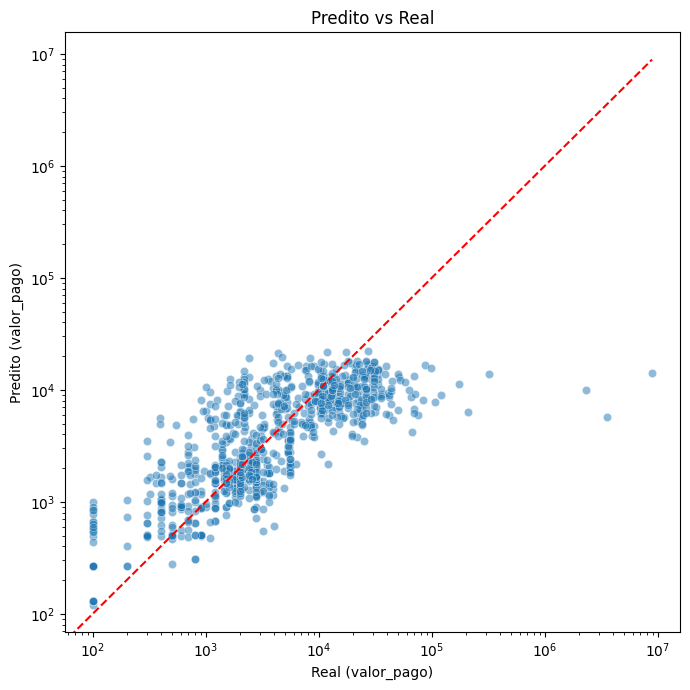

R² (escala real, log-transform invertida): -0.00115155367259967


In [10]:
# Gráfico predição x real (escala real)

y_true = y_test_real
y_pred = preds_real

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)

lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')

plt.xlabel('Real (valor_pago)')
plt.ylabel('Predito (valor_pago)')
plt.title('Predito vs Real')
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()

print('R² (escala real, log-transform invertida):', r2_score(y_true, y_pred))

   decile  count            MAE           RMSE
0       0  106.0     821.931878    1802.950897
1       1   95.0    1378.674527    2399.339193
2       2   99.0    1331.246854    2471.689189
3       3  103.0    1941.060759    3598.587395
4       4  126.0    1234.193434    2183.397895
5       5   72.0    3154.390455    4471.538083
6       6  102.0    3399.467595    4319.322550
7       7   97.0    3178.665061    3852.189150
8       8  100.0    9255.182679   10469.162524
9       9  100.0  180084.739494  983732.577693


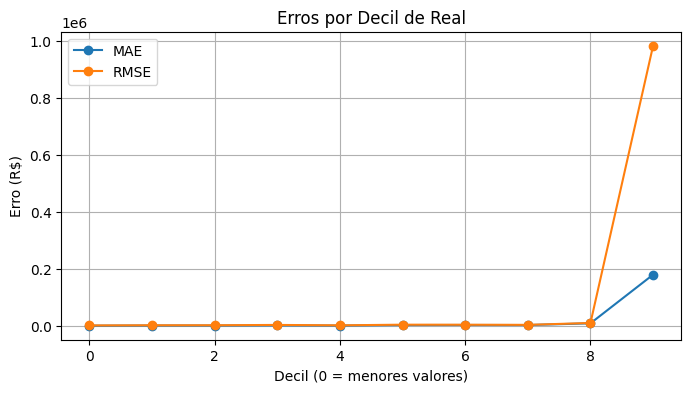

In [11]:
# Erros por decil (em valores reais)

df_errors = pd.DataFrame({'real': np.ravel(y_true), 'pred': np.ravel(y_pred)})
df_errors['decile'] = pd.qcut(df_errors['real'], 10, labels=False, duplicates='drop')

summary = df_errors.groupby('decile').apply(
    lambda g: pd.Series({
        'count': len(g),
        'MAE':  mean_absolute_error(g['real'], g['pred']),
        'RMSE': math.sqrt(mean_squared_error(g['real'], g['pred']))
    })
).reset_index()

print(summary)

plt.figure(figsize=(8, 4))
plt.plot(summary['decile'], summary['MAE'],  marker='o', label='MAE')
plt.plot(summary['decile'], summary['RMSE'], marker='o', label='RMSE')
plt.xlabel('Decil (0 = menores valores)')
plt.ylabel('Erro (R$)')
plt.title('Erros por Decil de Real')
plt.legend()
plt.grid(True)
plt.show()